## Split Analysis

Loads the pre-processed split files and checks two things:

1. **Class balance** — label distribution within and across train / val / test.
2. **Per-subject split integrity** — no subject leaks across splits.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

PROCESSED = "outputs/processed"
SPLIT_ORDER = ["train", "val", "test"]
SPLIT_PALETTE = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}

In [2]:
df = pd.read_csv(f"{PROCESSED}/features_with_split.csv")
df["split"] = pd.Categorical(df["split"], categories=SPLIT_ORDER, ordered=True)

print(f"Total rows : {len(df):,}")
print(f"Subjects   : {df['id'].nunique()}")
print(f"Labels     : {df['label'].nunique()}")
print()
print(df.groupby("split", observed=True).agg(
    rows=("id", "count"),
    subjects=("id", "nunique"),
    labels=("label", "nunique"),
))

Total rows : 9,959
Subjects   : 30
Labels     : 67

       rows  subjects  labels
split                        
train  7058        21      67
val    1273         4      67
test   1628         5      67


### 1 Per-Subject Split Integrity

Each subject must appear in exactly one split. Any overlap means label leakage.


In [ ]:
# Leak check 
subject_splits = df.groupby("id")["split"].nunique()
leaking = subject_splits[subject_splits > 1]
if leaking.empty:
    print("No leakage — every subject belongs to exactly one split.")
else:
    print(f"WARNING: {len(leaking)} subject(s) span multiple splits:", leaking.index.tolist())

No leakage — every subject belongs to exactly one split.


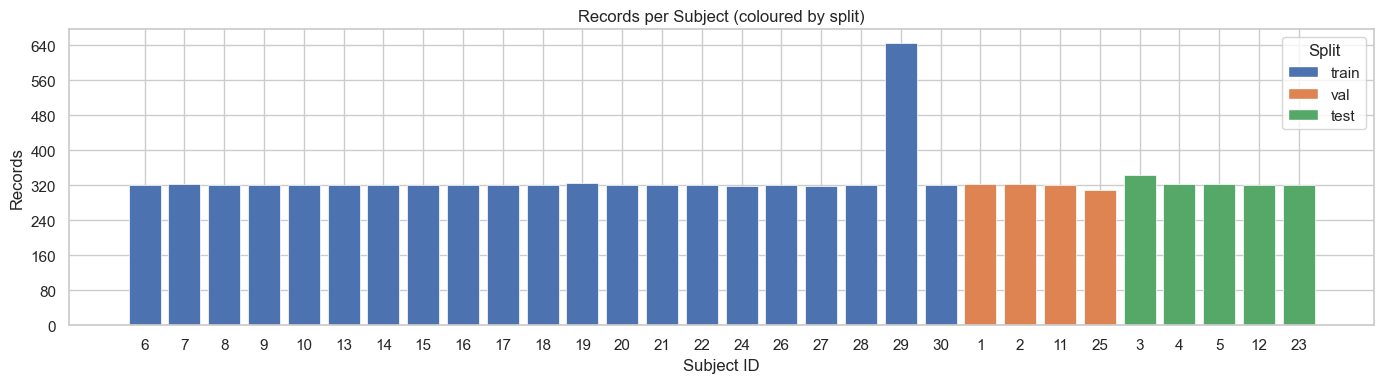

In [ ]:
# Records-per-subject bar chart, coloured by split 
subject_info = (
    df.groupby(["id", "split"], observed=True)
    .size()
    .reset_index(name="records")
    .sort_values(["split", "id"])
)

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(
    subject_info["id"].astype(str),
    subject_info["records"],
    color=[SPLIT_PALETTE[s] for s in subject_info["split"]],
    edgecolor="white",
    linewidth=0.5,
)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=SPLIT_PALETTE[s], label=s) for s in SPLIT_ORDER]
ax.legend(handles=legend_handles, title="Split", framealpha=0.8)

ax.set_xlabel("Subject ID")
ax.set_ylabel("Records")
ax.set_title("Records per Subject (coloured by split)")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

### 2 Class Balance

#### 2a Overall label frequency


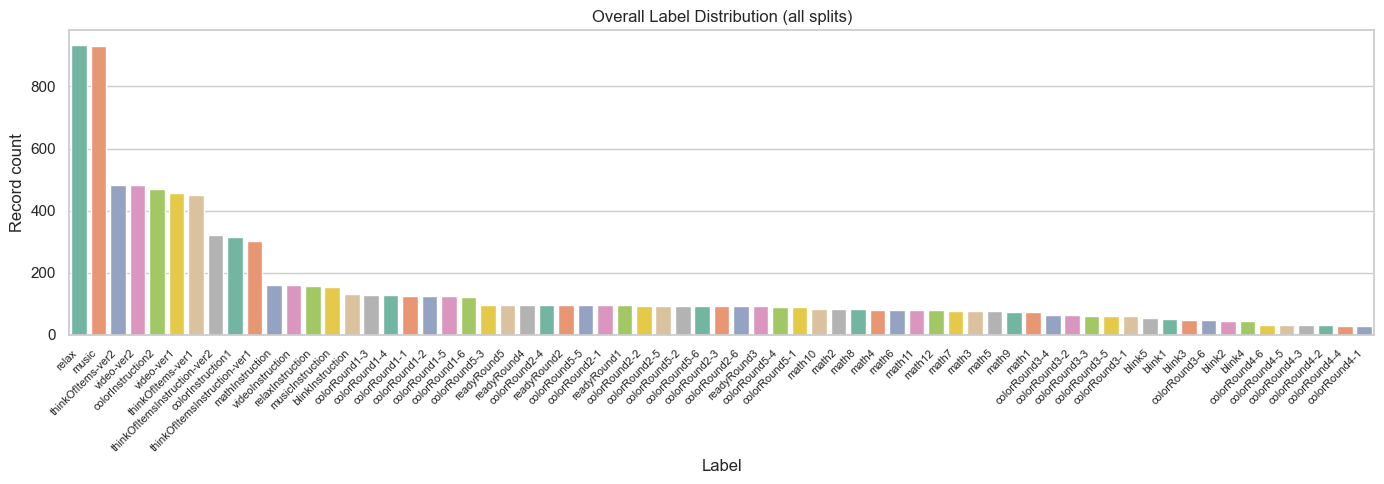

In [12]:
label_counts = df["label"].value_counts().reset_index()
label_counts.columns = ["label", "count"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(
    data=label_counts,
    x="label", y="count",
    palette="Set2",
    ax=ax, hue="label"
)
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_title("Overall Label Distribution (all splits)")
ax.set_xlabel("Label")
ax.set_ylabel("Record count")
plt.tight_layout()
plt.show()

#### 2b Label distribution per split (normalised)

Proportions should look similar across train / val / test if the natural class distribution is preserved.


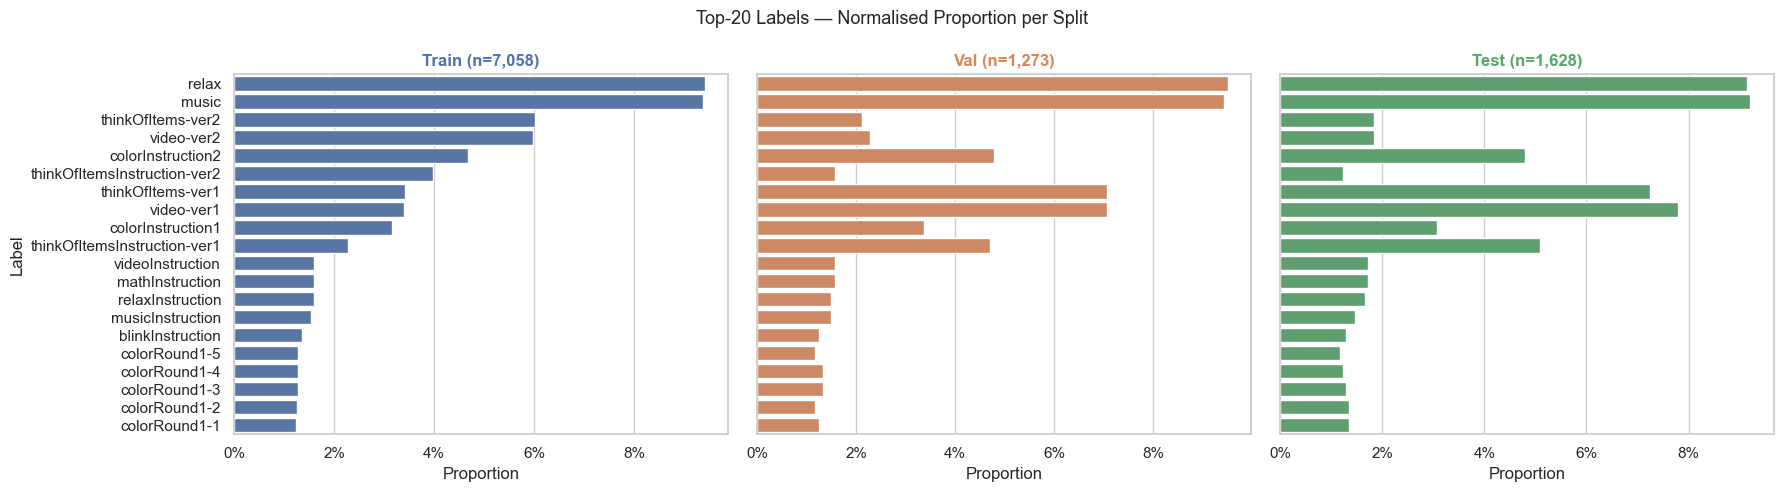

In [ ]:
split_label = (
    df.groupby(["split", "label"], observed=True)
    .size()
    .rename("count")
    .reset_index()
)
# Normalise within each split
split_totals = split_label.groupby("split", observed=True)["count"].transform("sum")
split_label["proportion"] = split_label["count"] / split_totals

# Top-N labels for readability
TOP_N = 20
top_labels = label_counts["label"].head(TOP_N).tolist()
plot_df = split_label[split_label["label"].isin(top_labels)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, split in zip(axes, SPLIT_ORDER):
    data = plot_df[plot_df["split"] == split].sort_values("proportion", ascending=False)
    sns.barplot(
        data=data, x="proportion", y="label",
        color=SPLIT_PALETTE[split], ax=ax
    )
    ax.set_title(f"{split.capitalize()} (n={df[df['split']==split].shape[0]:,})",
                color=SPLIT_PALETTE[split], fontweight="bold")
    ax.set_xlabel("Proportion")
    ax.set_ylabel("" if ax != axes[0] else "Label")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig.suptitle(f"Top-{TOP_N} Labels — Normalised Proportion per Split", fontsize=13)
plt.tight_layout()
plt.show()

#### 2c Imbalance ratio

Ratio of the most-frequent to least-frequent label in the training set — guides whether class weighting or oversampling is needed.


In [16]:
train_counts = df[df["split"] == "train"]["label"].value_counts()
ratio = train_counts.iloc[0] / train_counts.iloc[-1]
print(f"Most frequent  : {train_counts.index[0]}  ({train_counts.iloc[0]:,} rows)")
print(f"Least frequent : {train_counts.index[-1]}  ({train_counts.iloc[-1]:,} rows)")
print(f"Imbalance ratio: {ratio:.1f}x")

if ratio > 10:
    print("\n !! Severe imbalance. Consider class_weight='balanced' or oversampling.")
elif ratio > 3:
    print("\n Moderate imbalance. Monitor per-class recall.")
else:
    print("\n Mild imbalance. Standard training should work.")

Most frequent  : relax  (664 rows)
Least frequent : colorRound4-6  (21 rows)
Imbalance ratio: 31.6x

 !! Severe imbalance. Consider class_weight='balanced' or oversampling.


#### 2d Label × Subject heatmap (train set)

Checks whether some subjects are over-represented in specific label categories, which can inflate apparent model performance.


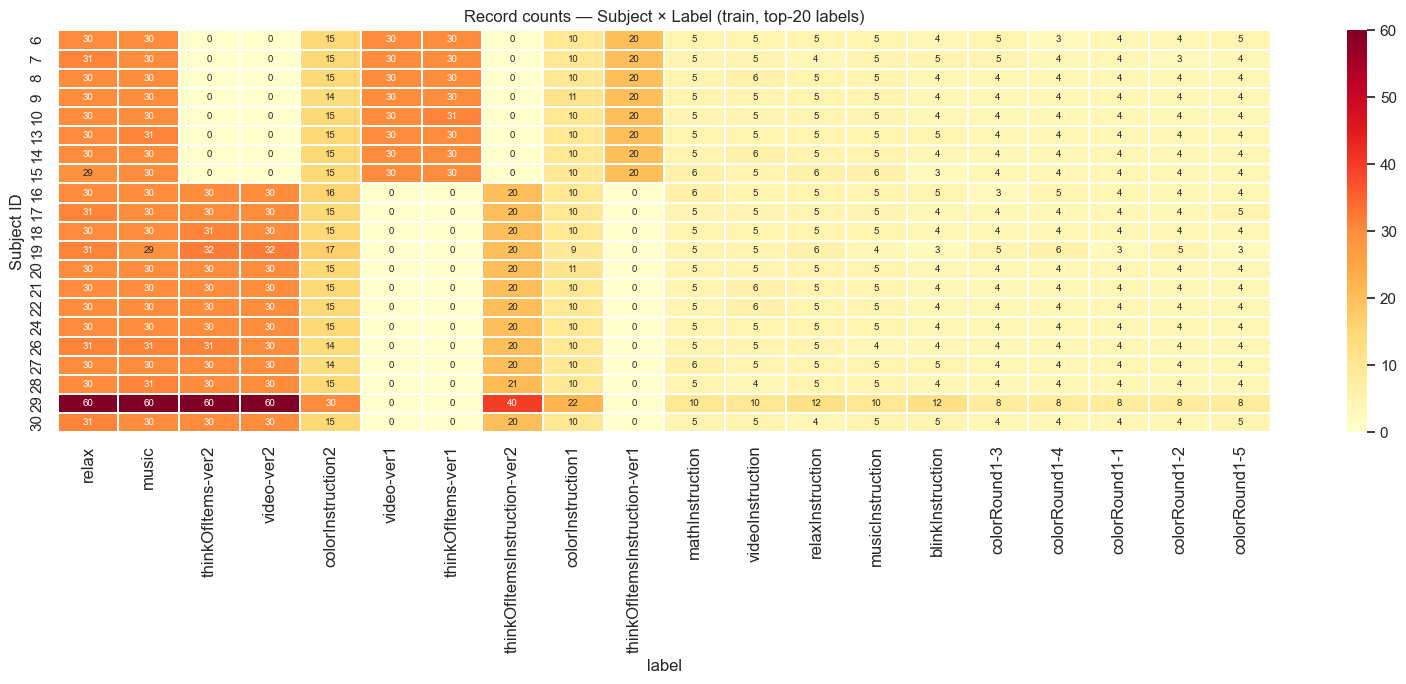

In [20]:
train_df = df[df["split"] == "train"]
pivot = (
    train_df.groupby(["id", "label"])
    .size()
    .unstack(fill_value=0)
)
# Keep only the top-N labels to keep the chart legible
pivot = pivot[top_labels]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    fmt="d",
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(f"Record counts — Subject × Label (train, top-{TOP_N} labels)")
# ax.set_xlabel("Label")
ax.set_ylabel("Subject ID")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=12)
plt.tight_layout()
plt.show()